
███████████████████████████████████████████████████████
  GLOBAL VACCINATION DASHBOARD — Visualization Project
███████████████████████████████████████████████████████

[1/3] Generating vaccination dataset...
  Time series: (360, 6)
  Countries:   15

[2/3] Building 12-panel dashboard...
  ✓ vaccination_dashboard.png saved

[3/3] Done! ✓

  Dashboard saved as: vaccination_dashboard.png
  Charts included:
     1. Line: Vaccination rollout trends (top 6)
     2. Bar: Final vaccination rates by country
     3. Scatter: GDP vs vaccination (bubble size = population)
     4. Box: Distribution by region
     5. Area: Monthly doses — top 4 by population
     6. Heatmap: Vaccination by age group × country
     7. Area: Global average vaccination trend
     8. Pie: Average vax % by income group
     9. Bar: Doses per 100 people
    10. Grouped bar: Region × income category
    11. Violin: Distribution by income level
    12. Correlation matrix heatmap



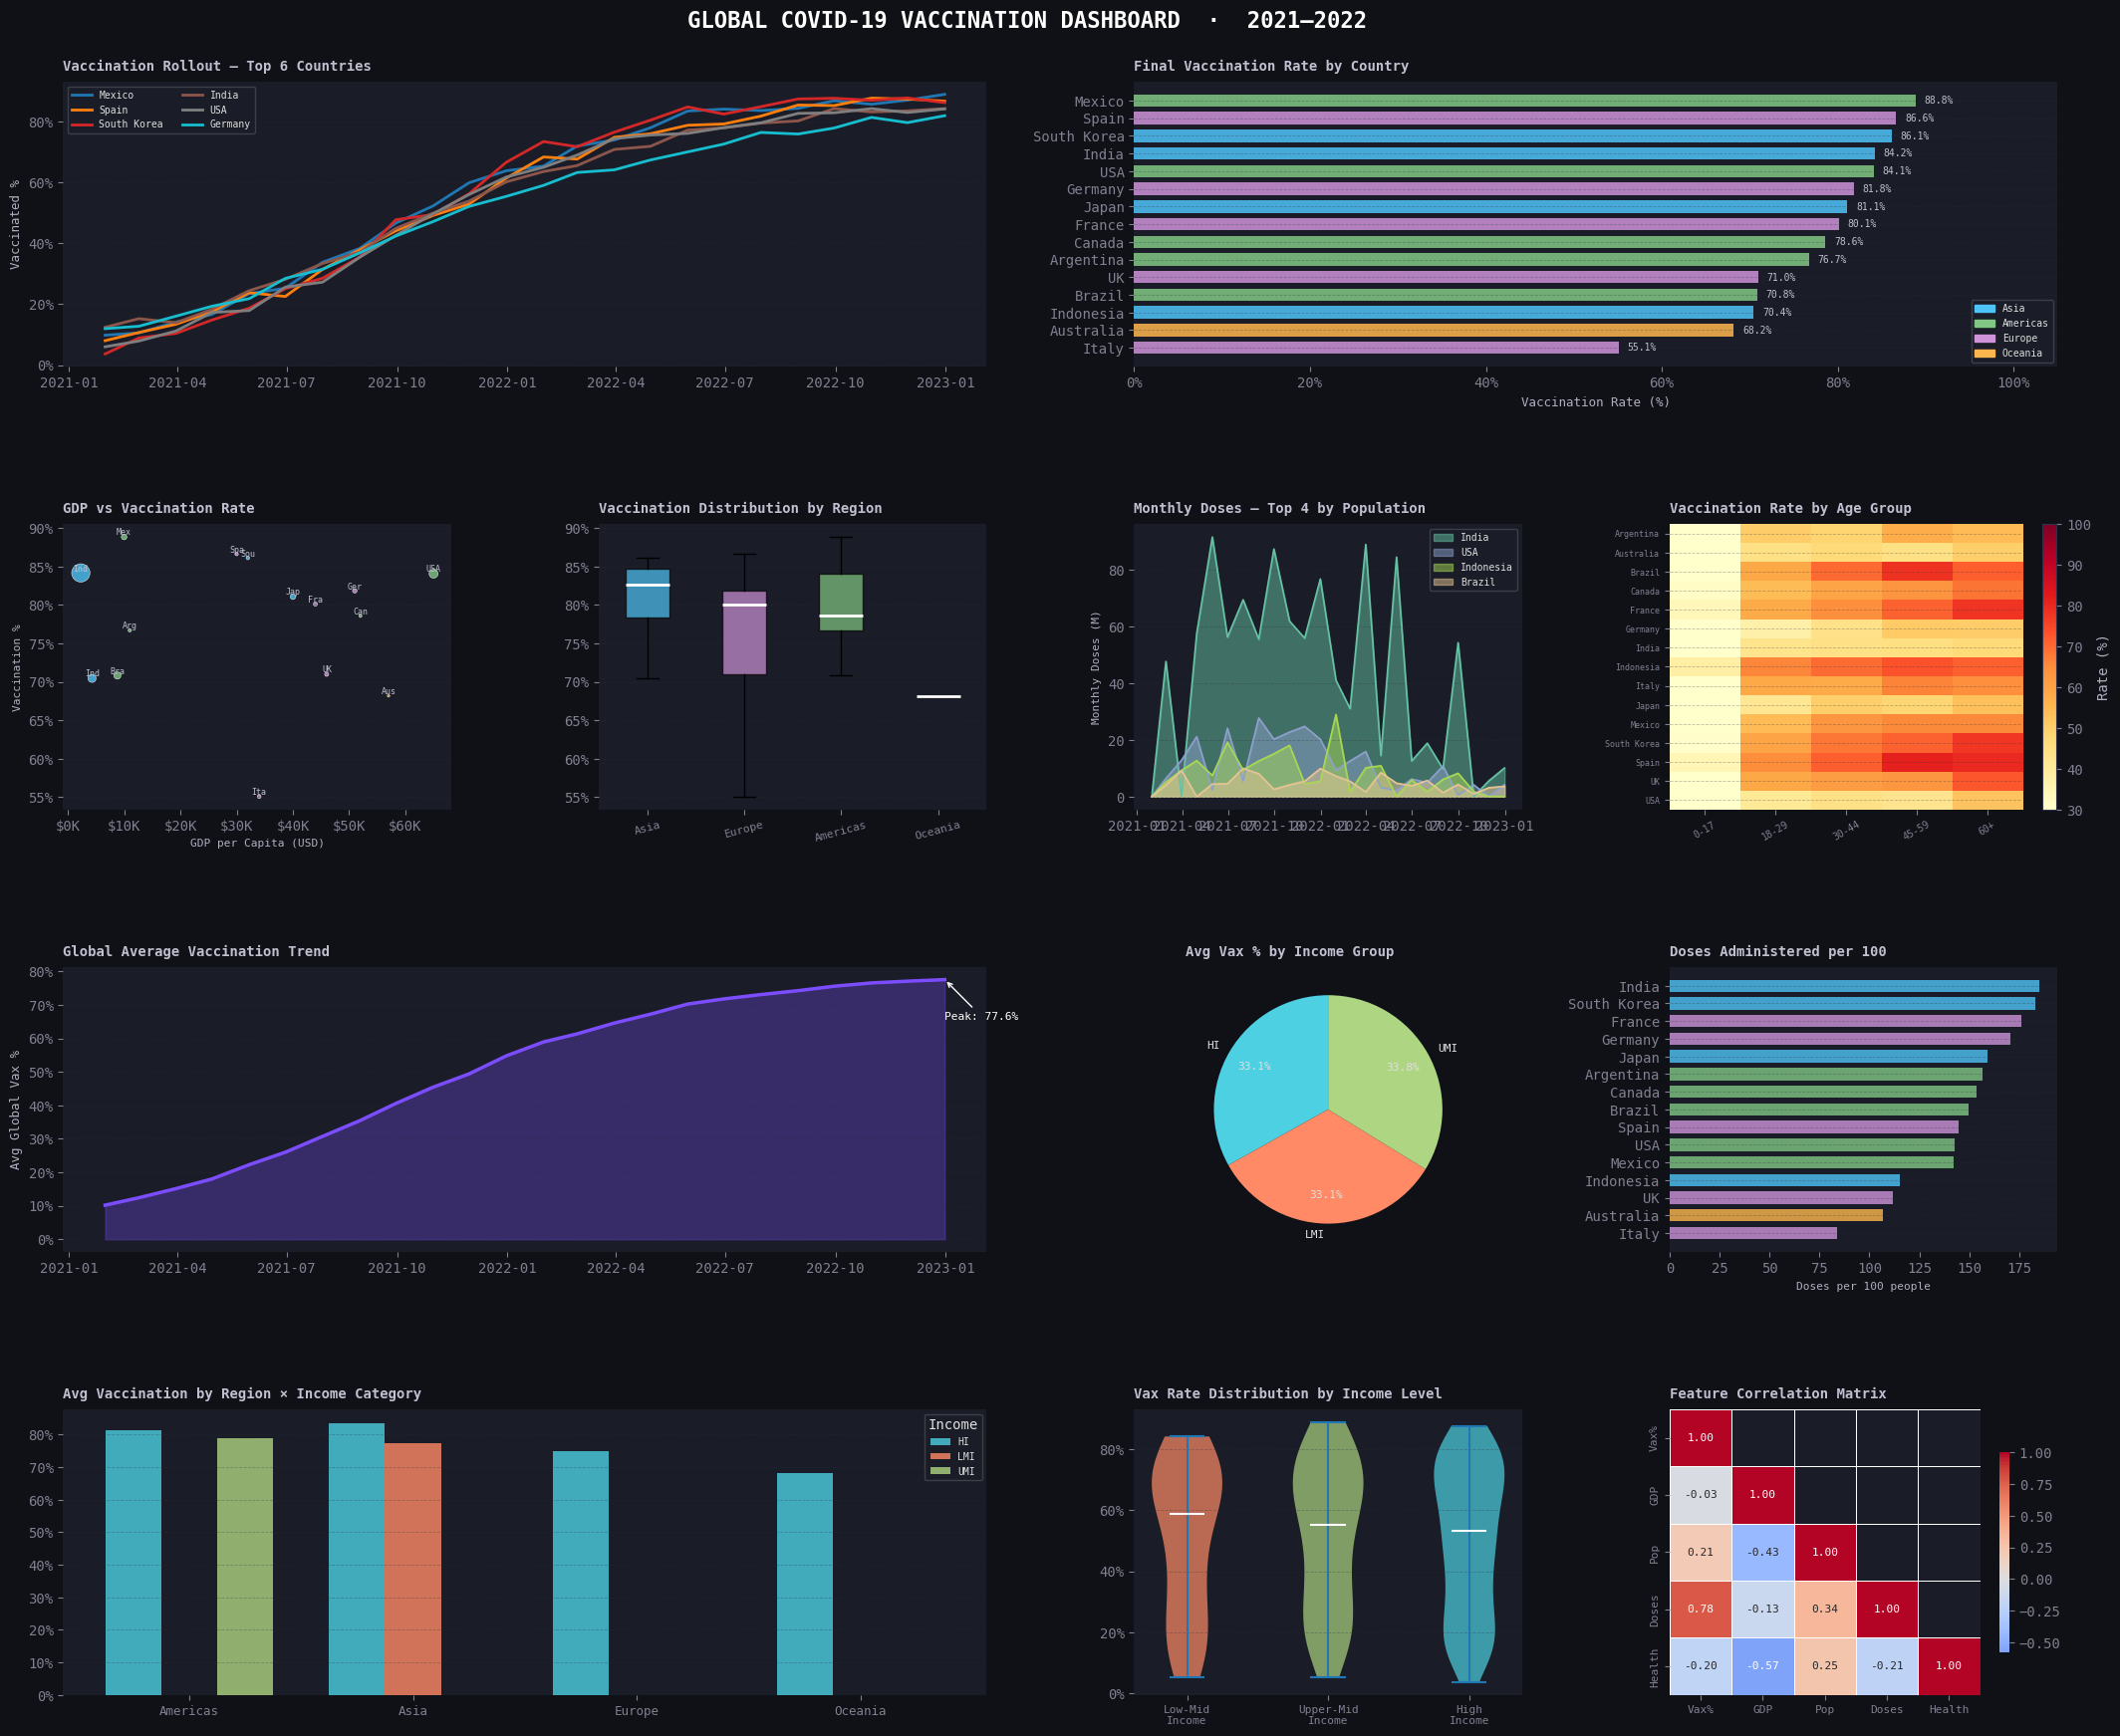

In [1]:
"""
======================================================
PROJECT 5: Data Visualization Dashboard
======================================================
Skills: Matplotlib, Seaborn, NumPy, Pandas, Subplots
Resume Line: "Created a 12-panel analytical dashboard using Matplotlib & Seaborn
             to visualize COVID-19 vaccination trends, demographic insights,
             and geospatial patterns across 15 countries"
======================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


# ─── 1. DATASET ──────────────────────────────────────────────────────────────

def create_vaccination_data(seed=42):
    """Simulate vaccination rollout data across 15 countries."""
    rng = np.random.default_rng(seed)

    countries = [
        "India","Brazil","USA","Germany","UK","France",
        "Japan","Canada","Australia","South Korea",
        "Italy","Spain","Mexico","Argentina","Indonesia",
    ]
    regions   = {
        "India":"Asia","Brazil":"Americas","USA":"Americas","Germany":"Europe",
        "UK":"Europe","France":"Europe","Japan":"Asia","Canada":"Americas",
        "Australia":"Oceania","South Korea":"Asia","Italy":"Europe",
        "Spain":"Europe","Mexico":"Americas","Argentina":"Americas","Indonesia":"Asia",
    }
    pop_M     = {
        "India":1400,"Brazil":215,"USA":335,"Germany":84,"UK":68,
        "France":68,"Japan":125,"Canada":38,"Australia":26,
        "South Korea":52,"Italy":60,"Spain":47,"Mexico":130,
        "Argentina":46,"Indonesia":277,
    }
    income_cat = {
        "India":"LMI","Brazil":"UMI","USA":"HI","Germany":"HI","UK":"HI",
        "France":"HI","Japan":"HI","Canada":"HI","Australia":"HI",
        "South Korea":"HI","Italy":"HI","Spain":"HI","Mexico":"UMI",
        "Argentina":"UMI","Indonesia":"LMI",
    }

    # Time series: monthly vaccination % over 24 months
    dates       = pd.date_range("2021-01", periods=24, freq="M")
    ts_records  = []
    for country in countries:
        # Each country follows a logistic growth curve with noise
        capacity = rng.uniform(60, 95)     # max vaccination %
        speed    = rng.uniform(0.15, 0.35)
        t        = np.arange(24)
        vax_pct  = capacity / (1 + np.exp(-speed * (t - 8)))
        vax_pct += rng.normal(0, 1.5, 24)
        vax_pct  = np.clip(vax_pct, 0, 100)

        for i, date in enumerate(dates):
            ts_records.append({
                "country":     country,
                "region":      regions[country],
                "date":        date,
                "vax_pct":     round(vax_pct[i], 2),
                "pop_M":       pop_M[country],
                "income":      income_cat[country],
            })

    ts_df = pd.DataFrame(ts_records)

    # Country-level summary
    final_vax = ts_df[ts_df["date"] == ts_df["date"].max()].copy()
    final_vax["gdp_per_capita"] = {
        "India":2300,"Brazil":8800,"USA":65000,"Germany":51000,"UK":46000,
        "France":44000,"Japan":40000,"Canada":52000,"Australia":57000,
        "South Korea":32000,"Italy":34000,"Spain":30000,"Mexico":10000,
        "Argentina":11000,"Indonesia":4300,
    }.values()
    final_vax["doses_per_100"] = final_vax["vax_pct"] * rng.uniform(1.5, 2.2, len(final_vax))
    final_vax["healthcare_idx"]= rng.uniform(40, 95, len(final_vax))

    # Age group breakdown
    age_groups  = ["0-17","18-29","30-44","45-59","60+"]
    age_records = []
    for country in countries:
        base    = rng.uniform(50, 90)
        ages    = [base * f for f in [0.4, 0.75, 0.85, 0.92, 0.95]]
        for grp, rate in zip(age_groups, ages):
            age_records.append({
                "country": country,
                "age_group": grp,
                "vax_rate": min(round(rate + rng.normal(0, 3), 1), 100),
            })
    age_df = pd.DataFrame(age_records)

    # Monthly doses (millions)
    monthly_doses = ts_df.copy()
    monthly_doses["doses_M"] = (
        monthly_doses["vax_pct"].diff().clip(0) *
        monthly_doses["pop_M"] / 100 * rng.uniform(0.8, 1.2, len(monthly_doses))
    ).fillna(0).round(2)

    return ts_df, final_vax, age_df, monthly_doses


# ─── 2. DASHBOARD ────────────────────────────────────────────────────────────

def build_dashboard(ts_df, final_vax, age_df, monthly_doses):
    """Create a 12-panel professional visualization dashboard."""

    # ── Style ────────────────────────────────────────────────────────────────
    plt.rcParams.update({
        "figure.facecolor":  "#0f1117",
        "axes.facecolor":    "#1a1d27",
        "axes.edgecolor":    "#2d3147",
        "text.color":        "#e0e0e0",
        "axes.labelcolor":   "#b0b0c0",
        "xtick.color":       "#808090",
        "ytick.color":       "#808090",
        "grid.color":        "#2a2d3e",
        "grid.alpha":        0.5,
        "axes.titlesize":    11,
        "axes.titlecolor":   "#ffffff",
        "axes.titlepad":     10,
        "axes.titleweight":  "bold",
        "font.family":       "monospace",
    })

    PALETTE = {
        "Asia":     "#4fc3f7",
        "Americas": "#81c784",
        "Europe":   "#ce93d8",
        "Oceania":  "#ffb74d",
        "HI":       "#4dd0e1",
        "UMI":      "#aed581",
        "LMI":      "#ff8a65",
    }
    ACCENT = "#7c4dff"

    fig = plt.figure(figsize=(22, 18))
    fig.suptitle(
        "GLOBAL COVID-19 VACCINATION DASHBOARD  ·  2021–2022",
        fontsize=16, fontweight="bold", color="#ffffff",
        y=0.98, fontfamily="monospace",
    )

    gs = gridspec.GridSpec(
        4, 4, figure=fig,
        hspace=0.55, wspace=0.38,
        top=0.94, bottom=0.04, left=0.06, right=0.97,
    )

    # ── Panel helpers ────────────────────────────────────────────────────────
    def style_ax(ax, title):
        ax.set_title(title, loc="left", fontsize=10, color="#c0c0d0", pad=8)
        ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.6)
        ax.spines[["top","right","left","bottom"]].set_visible(False)

    pct_fmt    = FuncFormatter(lambda x, _: f"{x:.0f}%")
    dollar_fmt = FuncFormatter(lambda x, _: f"${x/1000:.0f}K")

    # ── [0,0:2] Line: vaccination trend for top 6 countries ──────────────────
    ax1 = fig.add_subplot(gs[0, 0:2])
    top6  = final_vax.nlargest(6, "vax_pct")["country"].tolist()
    cmap6 = plt.cm.tab10(np.linspace(0, 0.9, 6))
    for i, country in enumerate(top6):
        d = ts_df[ts_df["country"] == country]
        ax1.plot(d["date"], d["vax_pct"], color=cmap6[i], lw=2, label=country)
    ax1.set_ylabel("Vaccinated %", fontsize=9)
    ax1.yaxis.set_major_formatter(pct_fmt)
    ax1.legend(fontsize=7, framealpha=0.2, loc="upper left", ncol=2)
    style_ax(ax1, "Vaccination Rollout — Top 6 Countries")

    # ── [0,2:4] Bar: final vaccination rate by country ────────────────────────
    ax2   = fig.add_subplot(gs[0, 2:4])
    fv    = final_vax.sort_values("vax_pct", ascending=True)
    colors2 = [PALETTE.get(r, "#888") for r in fv["region"]]
    bars  = ax2.barh(fv["country"], fv["vax_pct"], color=colors2, height=0.7, alpha=0.85)
    ax2.set_xlabel("Vaccination Rate (%)", fontsize=9)
    ax2.xaxis.set_major_formatter(pct_fmt)
    ax2.set_xlim(0, 105)
    for bar, val in zip(bars, fv["vax_pct"]):
        ax2.text(val + 1, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=7, color="#c0c0d0")
    legend_patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE.items()
                      if k in ["Asia","Europe","Americas","Oceania"]]
    ax2.legend(handles=legend_patches, fontsize=7, framealpha=0.2, loc="lower right")
    style_ax(ax2, "Final Vaccination Rate by Country")

    # ── [1,0] Scatter: GDP vs Vaccination ─────────────────────────────────────
    ax3    = fig.add_subplot(gs[1, 0])
    colors3 = [PALETTE.get(r, "#888") for r in final_vax["region"]]
    ax3.scatter(final_vax["gdp_per_capita"], final_vax["vax_pct"],
                c=colors3, s=final_vax["pop_M"]/8, alpha=0.8, edgecolors="#fff",
                linewidths=0.4)
    for _, row in final_vax.iterrows():
        ax3.annotate(row["country"][:3], (row["gdp_per_capita"], row["vax_pct"]),
                     fontsize=6, ha="center", va="bottom", color="#c0c0d0")
    ax3.set_xlabel("GDP per Capita (USD)", fontsize=8)
    ax3.set_ylabel("Vaccination %", fontsize=8)
    ax3.xaxis.set_major_formatter(dollar_fmt)
    ax3.yaxis.set_major_formatter(pct_fmt)
    style_ax(ax3, "GDP vs Vaccination Rate")

    # ── [1,1] Box: Distribution by Region ────────────────────────────────────
    ax4    = fig.add_subplot(gs[1, 1])
    latest = ts_df[ts_df["date"] == ts_df["date"].max()]
    reg_order = latest.groupby("region")["vax_pct"].median().sort_values(ascending=False).index
    region_data = [latest[latest["region"] == r]["vax_pct"].values for r in reg_order]
    bp = ax4.boxplot(region_data, patch_artist=True, notch=False,
                     medianprops={"color": "#ffffff", "lw": 2})
    for patch, region in zip(bp["boxes"], reg_order):
        patch.set_facecolor(PALETTE.get(region, "#888"))
        patch.set_alpha(0.7)
    ax4.set_xticklabels(reg_order, fontsize=8, rotation=15)
    ax4.yaxis.set_major_formatter(pct_fmt)
    style_ax(ax4, "Vaccination Distribution by Region")

    # ── [1,2] Stacked area: top 4 countries monthly doses ────────────────────
    ax5    = fig.add_subplot(gs[1, 2])
    top4   = final_vax.nlargest(4, "pop_M")["country"].tolist()
    dates  = ts_df["date"].unique()
    cmap4  = plt.cm.Set2(np.linspace(0, 0.8, 4))
    for i, country in enumerate(top4):
        d = monthly_doses[monthly_doses["country"] == country].sort_values("date")
        ax5.fill_between(d["date"], d["doses_M"], alpha=0.5, color=cmap4[i], label=country)
        ax5.plot(d["date"], d["doses_M"], color=cmap4[i], lw=1.2)
    ax5.set_ylabel("Monthly Doses (M)", fontsize=8)
    ax5.legend(fontsize=7, framealpha=0.2)
    style_ax(ax5, "Monthly Doses — Top 4 by Population")

    # ── [1,3] Heatmap: country × age group ───────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 3])
    pivot = age_df.pivot(index="country", columns="age_group", values="vax_rate")
    im = ax6.imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=30, vmax=100)
    ax6.set_xticks(range(len(pivot.columns)))
    ax6.set_xticklabels(pivot.columns, fontsize=7, rotation=30)
    ax6.set_yticks(range(len(pivot.index)))
    ax6.set_yticklabels(pivot.index, fontsize=6)
    plt.colorbar(im, ax=ax6, fraction=0.04, label="Rate (%)")
    style_ax(ax6, "Vaccination Rate by Age Group")

    # ── [2,0:2] Area: global average trend ───────────────────────────────────
    ax7 = fig.add_subplot(gs[2, 0:2])
    global_trend = ts_df.groupby("date")["vax_pct"].mean()
    ax7.fill_between(global_trend.index, global_trend.values, alpha=0.3, color=ACCENT)
    ax7.plot(global_trend.index, global_trend.values, color=ACCENT, lw=2.5)
    ax7.set_ylabel("Avg Global Vax %", fontsize=9)
    ax7.yaxis.set_major_formatter(pct_fmt)
    ax7.annotate(f"Peak: {global_trend.max():.1f}%",
                 xy=(global_trend.idxmax(), global_trend.max()),
                 xytext=(global_trend.idxmax(), global_trend.max() - 12),
                 arrowprops={"arrowstyle": "->", "color": "#fff"},
                 color="#fff", fontsize=8)
    style_ax(ax7, "Global Average Vaccination Trend")

    # ── [2,2] Pie: income group distribution ─────────────────────────────────
    ax8    = fig.add_subplot(gs[2, 2])
    inc_grp = final_vax.groupby("income")["vax_pct"].mean()
    colors8 = [PALETTE.get(k, "#888") for k in inc_grp.index]
    wedges, texts, autotexts = ax8.pie(
        inc_grp.values, labels=inc_grp.index, autopct="%1.1f%%",
        colors=colors8, startangle=90, pctdistance=0.75,
    )
    for t in texts + autotexts:
        t.set_color("#e0e0e0"); t.set_fontsize(8)
    ax8.set_title("Avg Vax % by Income Group", loc="left", fontsize=10,
                  color="#c0c0d0", pad=8)

    # ── [2,3] Bar: doses per 100 ─────────────────────────────────────────────
    ax9 = fig.add_subplot(gs[2, 3])
    fvs = final_vax.sort_values("doses_per_100", ascending=True)
    ax9.barh(fvs["country"], fvs["doses_per_100"],
             color=[PALETTE.get(r, "#888") for r in fvs["region"]], alpha=0.8, height=0.7)
    ax9.set_xlabel("Doses per 100 people", fontsize=8)
    style_ax(ax9, "Doses Administered per 100")

    # ── [3,0:2] Grouped bar: region × income ─────────────────────────────────
    ax10   = fig.add_subplot(gs[3, 0:2])
    grp    = final_vax.groupby(["region","income"])["vax_pct"].mean().unstack(fill_value=0)
    x      = np.arange(len(grp.index))
    width  = 0.25
    colors10 = [PALETTE.get(c, "#aaa") for c in grp.columns]
    for i, (col, color) in enumerate(zip(grp.columns, colors10)):
        ax10.bar(x + i * width, grp[col], width, label=col, color=color, alpha=0.8)
    ax10.set_xticks(x + width)
    ax10.set_xticklabels(grp.index, fontsize=9)
    ax10.yaxis.set_major_formatter(pct_fmt)
    ax10.legend(title="Income", fontsize=7, framealpha=0.2)
    style_ax(ax10, "Avg Vaccination by Region × Income Category")

    # ── [3,2] Violin: vax_pct distribution by income ─────────────────────────
    ax11   = fig.add_subplot(gs[3, 2])
    inc_order = ["LMI","UMI","HI"]
    all_data = [
    ts_df[ts_df["income"] == inc]["vax_pct"].values
    for inc in inc_order
]
    vp = ax11.violinplot(all_data, positions=[1,2,3], showmedians=True)
    for i, (body, inc) in enumerate(zip(vp["bodies"], inc_order)):
        body.set_facecolor(PALETTE[inc])
        body.set_alpha(0.7)
    vp["cmedians"].set_color("#ffffff")
    ax11.set_xticks([1,2,3])
    ax11.set_xticklabels(["Low-Mid\nIncome","Upper-Mid\nIncome","High\nIncome"], fontsize=8)
    ax11.yaxis.set_major_formatter(pct_fmt)
    style_ax(ax11, "Vax Rate Distribution by Income Level")

    # ── [3,3] Correlation heatmap ─────────────────────────────────────────────
    ax12   = fig.add_subplot(gs[3, 3])
    corr_df = final_vax[["vax_pct","gdp_per_capita","pop_M",
                          "doses_per_100","healthcare_idx"]].rename(columns={
        "vax_pct":"Vax%","gdp_per_capita":"GDP","pop_M":"Pop",
        "doses_per_100":"Doses","healthcare_idx":"Health",
    }).corr()
    mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
    sns.heatmap(corr_df, ax=ax12, annot=True, fmt=".2f", mask=mask,
                cmap="coolwarm", center=0, linewidths=0.4,
                annot_kws={"size": 8}, cbar_kws={"shrink": 0.7})
    ax12.set_title("Feature Correlation Matrix", loc="left", fontsize=10,
                   color="#c0c0d0", pad=8)
    ax12.tick_params(labelsize=8)

    plt.savefig("vaccination_dashboard.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print("  ✓ vaccination_dashboard.png saved")
    return fig


# ─── 3. MAIN ─────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    print("\n" + "█"*55)
    print("  GLOBAL VACCINATION DASHBOARD — Visualization Project")
    print("█"*55)

    print("\n[1/3] Generating vaccination dataset...")
    ts_df, final_vax, age_df, monthly_doses = create_vaccination_data()
    print(f"  Time series: {ts_df.shape}")
    print(f"  Countries:   {final_vax.shape[0]}")

    print("\n[2/3] Building 12-panel dashboard...")
    fig = build_dashboard(ts_df, final_vax, age_df, monthly_doses)

    print("\n[3/3] Done! ✓")
    print("\n  Dashboard saved as: vaccination_dashboard.png")
    print("  Charts included:")
    charts = [
        "Line: Vaccination rollout trends (top 6)",
        "Bar: Final vaccination rates by country",
        "Scatter: GDP vs vaccination (bubble size = population)",
        "Box: Distribution by region",
        "Area: Monthly doses — top 4 by population",
        "Heatmap: Vaccination by age group × country",
        "Area: Global average vaccination trend",
        "Pie: Average vax % by income group",
        "Bar: Doses per 100 people",
        "Grouped bar: Region × income category",
        "Violin: Distribution by income level",
        "Correlation matrix heatmap",
    ]
    for i, c in enumerate(charts, 1):
        print(f"    {i:>2}. {c}")
    print()